# TP — Analyse de Sentiment | Pipeline ML vs Transformer
## Phase 1 — Exploration et Préparation des Données

Objectif: préparer un jeu de données propre, reproductible et bien documenté avant d'entraîner les modèles.

## 1.1 Installation des dépendances

On installe dès le départ les bibliothèques nécessaires pour éviter les blocages plus tard, notamment pour le traitement des données, la visualisation et le futur fine-tuning CamemBERT.

In [ ]:
# Installation des bibliothèques utilisées dans le TP
%pip install -q transformers datasets torch scikit-learn pandas numpy matplotlib seaborn streamlit joblib sentencepiece protobuf

## 1.2 Chargement du dataset Allocine

On charge le dataset brut avant tout nettoyage pour mesurer sa taille, vérifier sa structure et partir d'une base identique pour tous les traitements.

In [6]:
from datasets import load_dataset
ds = load_dataset('tblard/allocine')

# 1. Voir la structure générale
print(ds)

#  Convertir en DataFrame pandas pour mieux visualiser
df = ds['train'].to_pandas()
print(df.head(10)  )




DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 160000
    })
    validation: Dataset({
        features: ['review', 'label'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 20000
    })
})
                                              review  label
0  Si vous cherchez du cinéma abrutissant à tous ...      0
1  Trash, re-trash et re-re-trash...! Une horreur...      0
2  Et si, dans les 5 premières minutes du film, l...      0
3  Mon dieu ! Quelle métaphore filée ! Je suis ab...      0
4  Premier film de la saga Kozure Okami, "Le Sabr...      1
5  L'amnésie est un thème en or pour susciter le ...      0
6  Tout commence comme une comédie légère avant u...      1
7  un excellent film qui merite ses quatre étoile...      1
8  Deuxième long métrage de Pasolini, Mamma Roma ...      1
9  Créateur de la célèbre série télévisée Kaamelo...      0


In [ ]:
# Imports de base et chargement du dataset Allocine
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split

random_state = 42
random.seed(random_state)
np.random.seed(random_state)

ds = load_dataset('tblard/allocine')

print(ds)
print('Splits disponibles:', list(ds.keys()))
print('Taille train:', len(ds['train']))

DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 160000
    })
    validation: Dataset({
        features: ['review', 'label'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 20000
    })
})
Splits disponibles: ['train', 'validation', 'test']
Taille train: 160000


## 1.3 Exploration des données (EDA)

On inspecte la distribution des classes, la longueur des avis et quelques exemples pour vérifier rapidement si le problème est équilibré et si les textes ont le format attendu.

Shape du dataset train: (160000, 2)
Colonnes: ['review', 'label']
NaN par colonne:
review    0
label     0
dtype: int64
Distribution des classes:
label
négatif    79413
positif    80587
Name: count, dtype: int64


/tmp/ipykernel_1419/4189440642.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index.map(label_names.get), y=label_counts.values, palette='viridis')


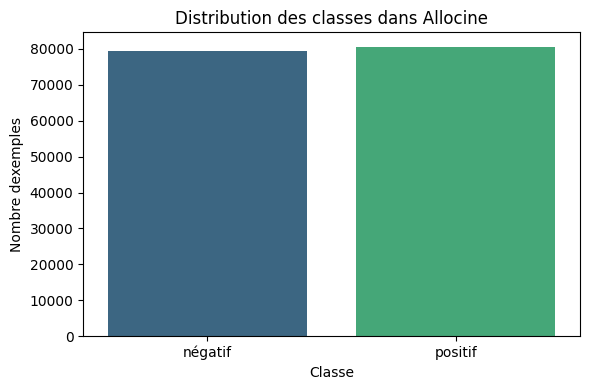

Longueur moyenne: 542.49
Longueur médiane: 389.0
Longueur max: 2000


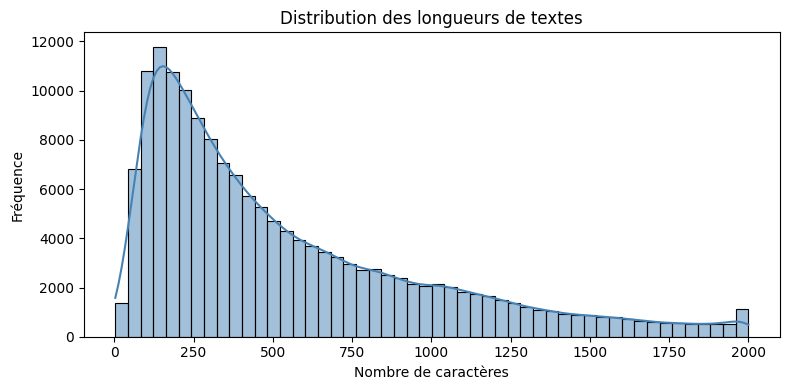

Exemples davis positifs:


,review
4,"Premier film de la saga Kozure Okami, ""Le Sabr..."
6,Tout commence comme une comédie légère avant u...
7,un excellent film qui merite ses quatre étoile...


Exemples davis négatifs:


,review
0,Si vous cherchez du cinéma abrutissant à tous ...
1,"Trash, re-trash et re-re-trash...! Une horreur..."
2,"Et si, dans les 5 premières minutes du film, l..."


In [ ]:
# Conversion en DataFrame pour faciliter l'EDA
df = pd.DataFrame(ds['train'])

print('Shape du dataset train:', df.shape)
print('Colonnes:', df.columns.tolist())
print('NaN par colonne:')
print(df.isna().sum())

# Distribution des classes
label_names = {0: 'négatif', 1: 'positif'}
label_counts = df['label'].value_counts().sort_index()
print('Distribution des classes:')
print(label_counts.rename(index=label_names))

plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index.map(label_names.get), y=label_counts.values, palette='viridis')
plt.title('Distribution des classes dans Allocine')
plt.xlabel('Classe')
plt.ylabel('Nombre dexemples')
plt.tight_layout()
plt.show()

# Longueur des textes
text_lengths = df['review'].astype(str).str.len()
print('Longueur moyenne:', round(text_lengths.mean(), 2))
print('Longueur médiane:', round(text_lengths.median(), 2))
print('Longueur max:', int(text_lengths.max()))

plt.figure(figsize=(8, 4))
sns.histplot(text_lengths, bins=50, kde=True, color='steelblue')
plt.title('Distribution des longueurs de textes')
plt.xlabel('Nombre de caractères')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()



## 1.4 Nettoyage du texte

On nettoie maintenant les avis pour réduire le bruit textuel et standardiser les entrées. Ce prétraitement améliore la qualité de la vectorisation TF-IDF et évite d'apprendre des artefacts inutiles comme les balises HTML.

In [ ]:
# Fonction de nettoyage du texte
def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test rapide sur un exemple contenant du HTML
exemple_test = 'Ce film <br> est bien <div>vraiment</div> !'
print('Avant:', exemple_test)
print('Après :', clean_text(exemple_test))

df['review_clean'] = df['review'].apply(clean_text)
print('NaN après nettoyage:')
print(df['review_clean'].isna().sum())
print('Chaînes vides après nettoyage:', (df['review_clean'].str.len() == 0).sum())

Avant: Ce film <br> est bien <div>vraiment</div> !
Après : ce film est bien vraiment !
NaN après nettoyage:
0
Chaînes vides après nettoyage: 0


## 1.5 Split Train / Validation / Test

On sépare les données en trois ensembles afin d'évaluer les modèles sur des données jamais vues et de conserver une validation indépendante pour les choix de modèles et d'hyperparamètres. La stratification maintient les proportions de classes proches dans chaque split.

In [ ]:
# Préparation des variables et split stratifié 80/10/10
X = df['review_clean'].tolist()
y = df['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=random_state
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=random_state
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print('Distribution train:', pd.Series(y_train).value_counts(normalize=True).sort_index().to_dict())
print('Distribution val  :', pd.Series(y_val).value_counts(normalize=True).sort_index().to_dict())
print('Distribution test :', pd.Series(y_test).value_counts(normalize=True).sort_index().to_dict())

Train: 128000 | Val: 16000 | Test: 16000
Distribution train: {0: 0.496328125, 1: 0.503671875}
Distribution val  : {0: 0.4963125, 1: 0.5036875}
Distribution test : {0: 0.496375, 1: 0.503625}


# Phase 2 — Pipeline ML Classique (TF-IDF + Classifieurs)

On construit maintenant une première famille de modèles rapides et interprétables pour établir une baseline solide avant de passer au Transformer.

## 2.1 Vectorisation TF-IDF

La vectorisation TF-IDF transforme les avis en vecteurs numériques exploitables par les classifieurs. On conserve les bigrammes pour capter des expressions de sentiment comme 'pas bon' ou 'très bien'.

In [ ]:
# Imports Phase 2 et préparation des outils de benchmark
import time
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

random_state = 42
tfidf_params = dict(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
)

print('Variables attendues en mémoire: X_train, X_val, X_test, y_train, y_val, y_test')
print('Taille train:', len(X_train))
print('Taille val  :', len(X_val))
print('Taille test :', len(X_test))

Variables attendues en mémoire: X_train, X_val, X_test, y_train, y_val, y_test
Taille train: 128000
Taille val  : 16000
Taille test : 16000


## 2.2 Modèle 1 — Régression Logistique (baseline)

La régression logistique est une excellente baseline pour les textes: elle est rapide, robuste et surtout interprétable grâce à ses coefficients, ce qui nous servira ensuite pour analyser les mots les plus influents.

In [ ]:
# Définition et entraînement du pipeline de régression logistique
pipeline_lr = make_pipeline(
    TfidfVectorizer(**tfidf_params),
    LogisticRegression(max_iter=1000, random_state=random_state)
)

start_fit = time.time()
pipeline_lr.fit(X_train, y_train)
fit_time_lr = time.time() - start_fit

start_pred = time.time()
pred_lr = pipeline_lr.predict(X_val)
inference_time_lr = time.time() - start_pred

metrics_lr = {
    'modele': 'Logistic Regression',
    'accuracy': accuracy_score(y_val, pred_lr),
    'f1_score': f1_score(y_val, pred_lr, average='weighted'),
    'precision': precision_score(y_val, pred_lr, average='weighted', zero_division=0),
    'recall': recall_score(y_val, pred_lr, average='weighted', zero_division=0),
    'temps_inference_s': inference_time_lr,
    'temps_fit_s': fit_time_lr,
}

print(metrics_lr)

{'modele': 'Logistic Regression', 'accuracy': 0.936, 'f1_score': 0.9359988899050175, 'precision': 0.9360043617898396, 'recall': 0.936, 'temps_inference_s': 2.3652493953704834, 'temps_fit_s': 42.048086404800415}


## 2.3 Modèle 2 — SVM LinearSVC

LinearSVC est souvent très performant sur les données textuelles clairsemées. Il complète bien la régression logistique en proposant une autre frontière de décision, souvent plus efficace sur des vecteurs TF-IDF.

In [ ]:
# Définition et entraînement du pipeline LinearSVC
pipeline_svm = make_pipeline(
    TfidfVectorizer(**tfidf_params),
    LinearSVC(random_state=random_state)
)

start_fit = time.time()
pipeline_svm.fit(X_train, y_train)
fit_time_svm = time.time() - start_fit

start_pred = time.time()
pred_svm = pipeline_svm.predict(X_val)
inference_time_svm = time.time() - start_pred

metrics_svm = {
    'modele': 'SVM LinearSVC',
    'accuracy': accuracy_score(y_val, pred_svm),
    'f1_score': f1_score(y_val, pred_svm, average='weighted'),
    'precision': precision_score(y_val, pred_svm, average='weighted', zero_division=0),
    'recall': recall_score(y_val, pred_svm, average='weighted', zero_division=0),
    'temps_inference_s': inference_time_svm,
    'temps_fit_s': fit_time_svm,
}

print(metrics_svm)

{'modele': 'SVM LinearSVC', 'accuracy': 0.9349375, 'f1_score': 0.9349372094878001, 'precision': 0.9349375106531135, 'recall': 0.9349375, 'temps_inference_s': 2.322282314300537, 'temps_fit_s': 43.65161323547363}


## 2.4 Modèle 3 — Random Forest

Random Forest sert de comparaison non linéaire. Sur des vecteurs TF-IDF très creux, il est souvent moins compétitif que les modèles linéaires, mais il reste utile pour vérifier si une approche par arbres capte des relations différentes.

In [ ]:
# Définition et entraînement du pipeline Random Forest
pipeline_rf = make_pipeline(
    TfidfVectorizer(**tfidf_params),
    RandomForestClassifier(
        n_estimators=200,
        random_state=random_state,
        n_jobs=-1
    )
)

start_fit = time.time()
pipeline_rf.fit(X_train, y_train)
fit_time_rf = time.time() - start_fit

start_pred = time.time()
pred_rf = pipeline_rf.predict(X_val)
inference_time_rf = time.time() - start_pred

metrics_rf = {
    'modele': 'Random Forest',
    'accuracy': accuracy_score(y_val, pred_rf),
    'f1_score': f1_score(y_val, pred_rf, average='weighted'),
    'precision': precision_score(y_val, pred_rf, average='weighted', zero_division=0),
    'recall': recall_score(y_val, pred_rf, average='weighted', zero_division=0),
    'temps_inference_s': inference_time_rf,
    'temps_fit_s': fit_time_rf,
}

print(metrics_rf)

{'modele': 'Random Forest', 'accuracy': 0.88825, 'f1_score': 0.8882440282384468, 'precision': 0.888488634964291, 'recall': 0.88825, 'temps_inference_s': 5.203643321990967, 'temps_fit_s': 1485.345728635788}


## 2.5 Optimisation des hyperparamètres (GridSearchCV)

On optimise seulement le meilleur candidat initial pour éviter une recherche trop coûteuse. L'objectif est de gagner un peu de performance sans exploser le temps d'exécution sur Colab.

In [ ]:
# Construction du tableau des résultats initiaux
resultats_ml = pd.DataFrame([metrics_lr, metrics_svm, metrics_rf])
resultats_ml = resultats_ml[['modele', 'accuracy', 'f1_score', 'precision', 'recall', 'temps_fit_s', 'temps_inference_s']]
print(resultats_ml)

meilleur_modele_initial = resultats_ml.sort_values('f1_score', ascending=False).iloc[0]['modele']
print('Meilleur modèle initial:', meilleur_modele_initial)

if meilleur_modele_initial == 'Logistic Regression':
    pipeline_best_base = make_pipeline(TfidfVectorizer(**tfidf_params), LogisticRegression(max_iter=1000, random_state=random_state))
    param_grid = {
        'logisticregression__C': [0.5, 1.0, 2.0, 4.0],
        'logisticregression__class_weight': [None, 'balanced']
    }
elif meilleur_modele_initial == 'SVM LinearSVC':
    pipeline_best_base = make_pipeline(TfidfVectorizer(**tfidf_params), LinearSVC(random_state=random_state))
    param_grid = {
        'linearsvc__C': [0.5, 1.0, 2.0, 4.0],
        'linearsvc__class_weight': [None, 'balanced']
    }
else:
    pipeline_best_base = make_pipeline(
        TfidfVectorizer(**tfidf_params),
        RandomForestClassifier(random_state=random_state, n_jobs=-1)
    )
    param_grid = {
        'randomforestclassifier__n_estimators': [200, 300],
        'randomforestclassifier__max_depth': [None, 50],
        'randomforestclassifier__min_samples_split': [2, 5]
    }

grid_search = GridSearchCV(
    pipeline_best_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

start_fit = time.time()
grid_search.fit(X_train, y_train)
grid_search_time = time.time() - start_fit

best_pipeline = grid_search.best_estimator_
pred_best = best_pipeline.predict(X_val)

metrics_best = {
    'modele': f'Best tuned: {meilleur_modele_initial}',
    'accuracy': accuracy_score(y_val, pred_best),
    'f1_score': f1_score(y_val, pred_best, average='weighted'),
    'precision': precision_score(y_val, pred_best, average='weighted', zero_division=0),
    'recall': recall_score(y_val, pred_best, average='weighted', zero_division=0),
    'temps_inference_s': 0.0,
    'temps_fit_s': grid_search_time,
}

print('Meilleurs paramètres:', grid_search.best_params_)
print(metrics_best)

                modele  accuracy  f1_score  precision    recall  temps_fit_s  \
0  Logistic Regression  0.936000  0.935999   0.936004  0.936000    42.048086   
1        SVM LinearSVC  0.934937  0.934937   0.934938  0.934937    43.651613   
2        Random Forest  0.888250  0.888244   0.888489  0.888250  1485.345729   

   temps_inference_s  
0           2.365249  
1           2.322282  
2           5.203643  
Meilleur modèle initial: Logistic Regression
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Meilleurs paramètres: {'logisticregression__C': 4.0, 'logisticregression__class_weight': 'balanced'}
{'modele': 'Best tuned: Logistic Regression', 'accuracy': 0.939375, 'f1_score': 0.9393747612742577, 'precision': 0.9393749922650825, 'recall': 0.939375, 'temps_inference_s': 0.0, 'temps_fit_s': 1214.5910069942474}


## 2.6 Analyse des variables influentes

Les coefficients de la régression logistique permettent d'interpréter les mots qui poussent la décision vers le positif ou le négatif. C'est un avantage important du ML classique pour expliquer les prédictions.

/tmp/ipykernel_4660/2596254072.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pos_words, x='coefficient', y='mot', ax=axes[0], palette='Greens_r')
/tmp/ipykernel_4660/2596254072.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_neg_words, x='coefficient', y='mot', ax=axes[1], palette='Reds_r')


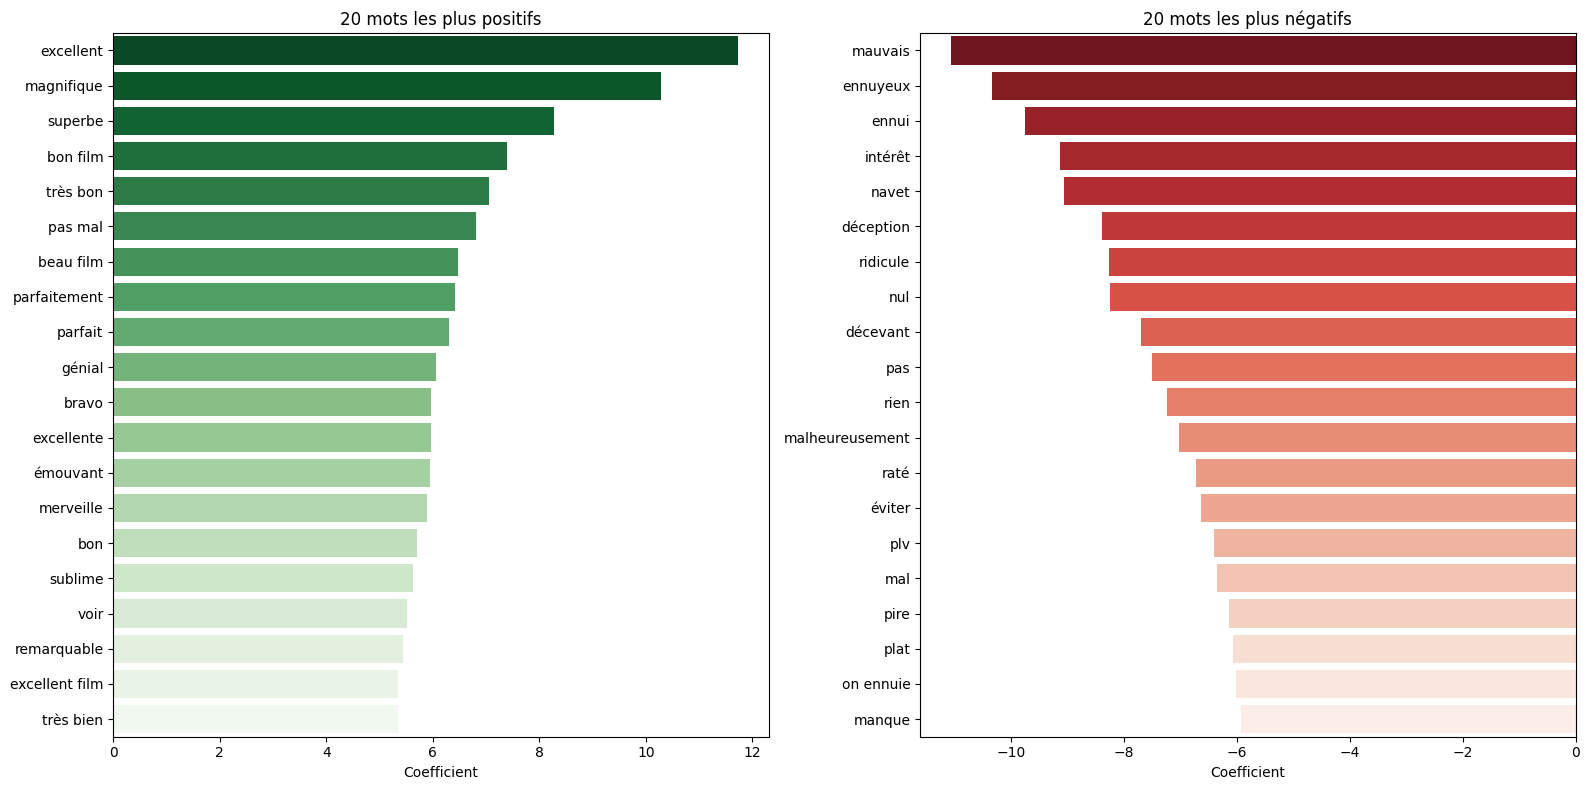

,mot,coefficient
0,excellent,11.721612
1,magnifique,10.277916
2,superbe,8.269994
3,bon film,7.401352
4,très bon,7.059992
5,pas mal,6.817118
6,beau film,6.464507
7,parfaitement,6.415991
8,parfait,6.308916
9,génial,6.066335


,mot,coefficient
0,mauvais,-11.056908
1,ennuyeux,-10.340399
2,ennui,-9.743693
3,intérêt,-9.131365
4,navet,-9.062224
5,déception,-8.381974
6,ridicule,-8.259081
7,nul,-8.239898
8,décevant,-7.695149
9,pas,-7.502581


In [ ]:
# Extraction des mots influents depuis la régression logistique
vectorizer_lr = pipeline_lr.named_steps['tfidfvectorizer']
classifier_lr = pipeline_lr.named_steps['logisticregression']
feature_names = vectorizer_lr.get_feature_names_out()
coefficients = classifier_lr.coef_[0]

top_pos_idx = coefficients.argsort()[-20:][::-1]
top_neg_idx = coefficients.argsort()[:20]

top_pos_words = pd.DataFrame({
    'mot': feature_names[top_pos_idx],
    'coefficient': coefficients[top_pos_idx]
})
top_neg_words = pd.DataFrame({
    'mot': feature_names[top_neg_idx],
    'coefficient': coefficients[top_neg_idx]
})

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.barplot(data=top_pos_words, x='coefficient', y='mot', ax=axes[0], palette='Greens_r')
axes[0].set_title('20 mots les plus positifs')
axes[0].set_xlabel('Coefficient')
axes[0].set_ylabel('')

sns.barplot(data=top_neg_words, x='coefficient', y='mot', ax=axes[1], palette='Reds_r')
axes[1].set_title('20 mots les plus négatifs')
axes[1].set_xlabel('Coefficient')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

display(top_pos_words)
display(top_neg_words)

## 2.7 Sauvegarde du meilleur modèle ML

On sauvegarde le pipeline final pour pouvoir le réutiliser directement dans le benchmark, puis dans l'application Streamlit, sans refaire l'entraînement.

In [ ]:
# Sauvegarde du meilleur pipeline sur Google Drive (persistant)
from google.colab import drive
drive.mount('/content/drive')

os.makedirs('/content/drive/MyDrive/TP_NLP', exist_ok=True)
joblib.dump(best_pipeline, '/content/drive/MyDrive/TP_NLP/model_ml.pkl')
print('Modèle sauvegardé dans /content/drive/MyDrive/TP_NLP/model_ml.pkl')
print('Fichier présent:', os.path.exists('/content/drive/MyDrive/TP_NLP/model_ml.pkl'))
print('\nRésumé Phase 2:')
print(resultats_ml)
print('\nMeilleur score validation:', resultats_ml['f1_score'].max())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modèle sauvegardé dans /content/drive/MyDrive/TP_NLP/model_ml.pkl
Fichier présent: True

Résumé Phase 2:
                modele  accuracy  f1_score  precision    recall  temps_fit_s  \
0  Logistic Regression  0.936000  0.935999   0.936004  0.936000    42.048086   
1        SVM LinearSVC  0.934937  0.934937   0.934938  0.934937    43.651613   
2        Random Forest  0.888250  0.888244   0.888489  0.888250  1485.345729   

   temps_inference_s  
0           2.365249  
1           2.322282  
2           5.203643  

Meilleur score validation: 0.9359988899050175


# Phase 3 — Fine-tuning du Transformer CamemBERT

Cette phase prépare un modèle contextualisé plus puissant que le ML classique. On exploite le GPU de Colab pour fine-tuner un Transformer pré-entraîné sur le français.

## 3.0 Vérification du GPU

On vérifie le GPU avant toute autre chose parce que le fine-tuning d'un Transformer sur 128 000 avis serait trop lent sur CPU. On affiche aussi le nom du GPU pour documenter l'environnement réel d'exécution.

In [ ]:
# Vérification de l'environnement GPU et des versions utiles
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

set_seed(42)

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print('GPU disponible:', gpu_name)
else:
    print('GPU non disponible - activer Runtime > GPU dans Colab')

print('Version torch:', torch.__version__)
print('Version numpy:', np.__version__)
print('Version pandas:', pd.__version__)

GPU disponible: Tesla T4
Version torch: 2.11.0+cu128
Version numpy: 2.0.2
Version pandas: 2.2.2


## 3.1 Tokenisation avec CamemBERT

On tokenize les textes avec un modèle pré-entraîné sur le français pour conserver le contexte des mots et des sous-mots. Le choix de 256 tokens limite le coût mémoire tout en couvrant la grande majorité des avis Allocine.

In [ ]:
import gc
import torch
from transformers import AutoTokenizer

max_length = 256
tokenizer = AutoTokenizer.from_pretrained('camembert-base')

print('Tokenizer chargé:', tokenizer.__class__.__name__)
print('Longueur maximale:', max_length)

def tokenize_in_batches(texts, tokenizer, max_length, batch_size=512):
    all_input_ids = []
    all_attention_masks = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encoded = tokenizer(
            batch,
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        all_input_ids.append(encoded['input_ids'].to(torch.int16))
        all_attention_masks.append(encoded['attention_mask'].to(torch.int16))
        del encoded

    return {
        'input_ids': torch.cat(all_input_ids, dim=0),
        'attention_mask': torch.cat(all_attention_masks, dim=0)
    }

train_encodings = tokenize_in_batches(X_train, tokenizer, max_length)
val_encodings   = tokenize_in_batches(X_val,   tokenizer, max_length)
test_encodings  = tokenize_in_batches(X_test,  tokenizer, max_length)

# Libération des données brutes
del X_train, X_val, X_test
gc.collect()

print('Exemple de clés tokenisées:', train_encodings.keys())
print('Taille input_ids train:', train_encodings['input_ids'].shape[0])

Tokenizer chargé: CamembertTokenizer
Longueur maximale: 256
Exemple de clés tokenisées: dict_keys(['input_ids', 'attention_mask'])
Taille input_ids train: 128000


## 3.2 Création du Dataset PyTorch

On encapsule les encodages dans une classe Dataset pour que HuggingFace Trainer puisse itérer proprement sur les lots. Cela permet de renvoyer des tenseurs PyTorch compatibles avec l'entraînement GPU.

In [ ]:
from torch.utils.data import Dataset
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Dataset PyTorch — recast int16 → int64 au moment du __getitem__
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.input_ids      = encodings['input_ids']       # int16 tensor
        self.attention_mask = encodings['attention_mask']  # int16 tensor
        self.labels         = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx].to(torch.long),
            'attention_mask': self.attention_mask[idx].to(torch.long),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = SentimentDataset(train_encodings, y_train)
val_dataset   = SentimentDataset(val_encodings,   y_val)
test_dataset  = SentimentDataset(test_encodings,  y_test)

# Libération des encodings bruts (le Dataset garde ses propres références)
del train_encodings, val_encodings, test_encodings
gc.collect()

print('Taille train_dataset:', len(train_dataset))
print('Exemple de batch:', train_dataset[0].keys())



Taille train_dataset: 128000
Exemple de batch: dict_keys(['input_ids', 'attention_mask', 'labels'])


## 3.3 Configuration du Trainer HuggingFace

On configure Trainer avec un learning rate faible pour éviter d'effacer brutalement les connaissances du modèle pré-entraîné. On active aussi load_best_model_at_end pour conserver automatiquement le meilleur compromis validé sur l'ensemble de validation.

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Chargement du modèle (les warnings UNEXPECTED/MISSING sont normaux)
model = AutoModelForSequenceClassification.from_pretrained(
    'camembert-base',
    num_labels=2
)

training_args = TrainingArguments(
    output_dir='/content/camembert_checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=100,
    save_total_limit=2,
    fp16=True,
    report_to='none',
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1':       f1_score(labels, predictions, average='weighted')
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,   # ← fix : remplace tokenizer=
    compute_metrics=compute_metrics,
)

print('Trainer configuré avec succès')
print('Output dir:', training_args.output_dir)
print('Learning rate:', training_args.learning_rate)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer configuré avec succès
Output dir: /content/camembert_checkpoints
Learning rate: 2e-05


## 3.4 Fine-tuning et courbes d'apprentissage

L'entraînement nous permet d'observer si le modèle apprend réellement ou s'il sur-apprend. Les courbes train_loss et eval_loss sur le même graphique sont utiles pour détecter rapidement un overfitting.

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.109915,0.118396,0.964750,0.964750
2,0.082518,0.127878,0.966875,0.966874
3,0.034428,0.156892,0.966688,0.966684


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Entraînement terminé


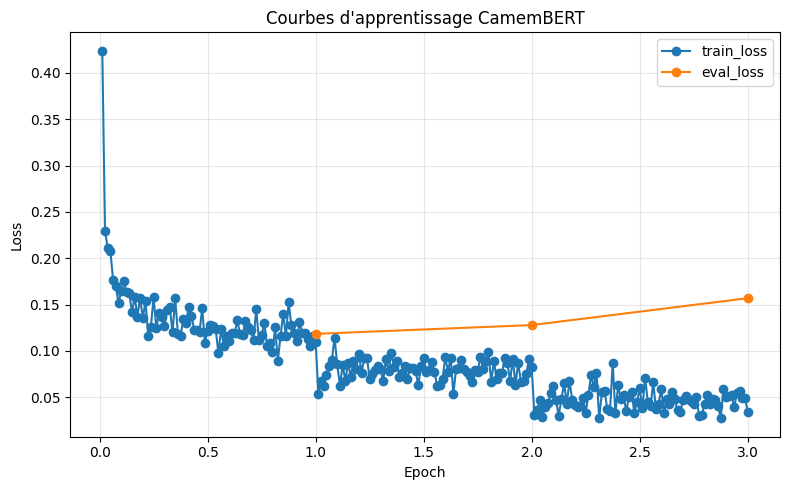

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.034428,0.127878,3,0.966875,0.966874


Métriques validation: {'eval_loss': 0.12787818908691406, 'eval_accuracy': 0.966875, 'eval_f1': 0.9668739129660919}


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Entraînement
train_result = trainer.train()
print('Entraînement terminé')

# Courbes de loss
log_history = pd.DataFrame(trainer.state.log_history)

train_loss_history = (
    log_history[log_history['loss'].notna()][['epoch', 'loss']]
    .drop_duplicates(subset=['epoch'], keep='last')
)
eval_loss_history = (
    log_history[log_history['eval_loss'].notna()][['epoch', 'eval_loss']]
    .drop_duplicates(subset=['epoch'], keep='last')
)

plt.figure(figsize=(8, 5))
if not train_loss_history.empty:
    plt.plot(train_loss_history['epoch'], train_loss_history['loss'],
             marker='o', label='train_loss')
if not eval_loss_history.empty:
    plt.plot(eval_loss_history['epoch'], eval_loss_history['eval_loss'],
             marker='o', label='eval_loss')
plt.title("Courbes d'apprentissage CamemBERT")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Évaluation finale sur la validation
metrics_val = trainer.evaluate()
print('Métriques validation:', metrics_val)

## 3.5 Sauvegarde du modèle

On sauvegarde le modèle fine-tuné sur Google Drive pour éviter de perdre plusieurs heures d'entraînement si la session Colab s'interrompt. On termine avec un test d'inférence rapide sur un avis positif et un avis négatif.

In [ ]:
# Sauvegarde sur Google Drive et test d'inférence rapide
from google.colab import drive
from transformers import pipeline as hf_pipeline

drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/TP_NLP/camembert_sentiment'
os.makedirs('/content/drive/MyDrive/TP_NLP', exist_ok=True)
trainer.save_model(save_path)
print('Modèle sauvegardé dans:', save_path)

classifier = hf_pipeline(
    'text-classification',
    model=save_path,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

exemple_positif = 'Ce film est une pure merveille, émouvant, brillant et parfaitement interprété.'
exemple_negatif = 'Ce film est long, ennuyeux et complètement raté du début à la fin.'

result_positif = classifier(exemple_positif)
result_negatif = classifier(exemple_negatif)

print('Exemple positif:', result_positif)
print('Exemple négatif:', result_negatif)
print('Phase 3 validée')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modèle sauvegardé dans: /content/drive/MyDrive/TP_NLP/camembert_sentiment


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Exemple positif: [{'label': 'LABEL_1', 'score': 0.9988394379615784}]
Exemple négatif: [{'label': 'LABEL_0', 'score': 0.9996492862701416}]
✅ Phase 3 validée


# Phase 4 — Benchmark et Comparaison des Modèles

Cette phase compare les modèles sur le même test set pour mesurer à la fois la qualité de classification et le coût d'inférence. Les résultats fictifs servent de repère visuel, mais les cellules calculent les vraies métriques sur les modèles chargés.

## 4.1 Chargement des modèles sauvegardés

On charge explicitement les artefacts sauvegardés pour garantir que la comparaison se fait à partir des versions finales et non de variables intermédiaires potentiellement modifiées en mémoire.

In [ ]:
# Imports et chargement des modèles sauvegardés
import time, os, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, torch
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix, roc_curve)
from transformers import pipeline
from google.colab import drive

drive.mount('/content/drive')

# Chemins Drive (persistants entre sessions)
ml_model_path   = '/content/drive/MyDrive/TP_NLP/model_ml.pkl'
bert_model_path = '/content/drive/MyDrive/TP_NLP/camembert_sentiment'

ml_model = joblib.load(ml_model_path)
bert_classifier = pipeline(
    'text-classification',
    model=bert_model_path,
    tokenizer='camembert-base',
    device=0 if torch.cuda.is_available() else -1
)
print(' Modèle ML chargé depuis', ml_model_path)
print(' CamemBERT chargé depuis', bert_model_path)
print('GPU disponible:', torch.cuda.is_available())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Modèle ML chargé depuis /content/drive/MyDrive/TP_NLP/model_ml.pkl
✅ CamemBERT chargé depuis /content/drive/MyDrive/TP_NLP/camembert_sentiment
GPU disponible: True


## 4.2 Évaluation sur le test set

On évalue tous les modèles sur exactement les mêmes exemples test pour obtenir une comparaison honnête. Les métriques incluent la performance de classification et le coût d'inférence, car le Transformer est plus lent mais potentiellement plus précis.

In [ ]:
# Fonctions utilitaires pour l'évaluation et la récupération des scores positifs

def _batched(items, batch_size):
    for start in range(0, len(items), batch_size):
        yield items[start:start + batch_size]


def get_sklearn_predictions_and_scores(model, texts):
    y_pred = np.asarray(model.predict(texts))
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(texts)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(texts)
    else:
        # REMPLACER PAR VALEURS RÉELLES si un estimateur sans score est utilisé
        y_score = y_pred.astype(float)
    return y_pred, np.asarray(y_score)


def get_bert_predictions_and_scores(classifier, texts, batch_size=32, max_length=256):
    model = classifier.model
    tokenizer = classifier.tokenizer
    device = model.device
    all_preds = []
    all_scores = []

    model.eval()
    for batch_texts in _batched(list(texts), batch_size):
        encodings = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors='pt'
        )
        encodings = {key: value.to(device) for key, value in encodings.items()}
        with torch.no_grad():
            logits = model(**encodings).logits
            probabilities = torch.softmax(logits, dim=-1)
        batch_preds = probabilities.argmax(dim=-1).detach().cpu().numpy()
        batch_scores = probabilities[:, 1].detach().cpu().numpy()
        all_preds.extend(batch_preds.tolist())
        all_scores.extend(batch_scores.tolist())

    return np.asarray(all_preds), np.asarray(all_scores)


def evaluate_predictions(name, y_true, y_pred, y_score, elapsed_s):
    return {
        'modele': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred, average='weighted'),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'auc_roc': roc_auc_score(y_true, y_score),
        'temps_inference_total_ms': elapsed_s * 1000,
        'temps_inference_par_prediction_ms': (elapsed_s / len(y_true)) * 1000,
    }


benchmark_results = []
prediction_store = {}

# Si les pipelines individuels de la Phase 2 sont encore en mémoire, on les compare.
# Sinon, on bascule sur le pipeline ML sauvegardé pour garder le notebook exécutable.
benchmark_specs = []
if all(name in globals() for name in ['pipeline_lr', 'pipeline_svm', 'pipeline_rf']):
    benchmark_specs = [
        ('Régression Log.', pipeline_lr),
        ('SVM LinearSVC', pipeline_svm),
        ('Random Forest', pipeline_rf),
        ('CamemBERT fine-tuné', bert_classifier),
    ]
else:
    benchmark_specs = [
        ('Modèle ML sauvegardé', ml_model),
        ('CamemBERT fine-tuné', bert_classifier),
    ]

for model_name, model_object in benchmark_specs:
    start_time = time.time()
    if model_name == 'CamemBERT fine-tuné':
        y_pred, y_score = get_bert_predictions_and_scores(model_object, X_test, batch_size=32, max_length=256)
    else:
        y_pred, y_score = get_sklearn_predictions_and_scores(model_object, X_test)
    elapsed_s = time.time() - start_time

    benchmark_results.append(evaluate_predictions(model_name, np.asarray(y_test), y_pred, y_score, elapsed_s))
    prediction_store[model_name] = {
        'y_pred': y_pred,
        'y_score': y_score,
    }

benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df = benchmark_df.set_index('modele')

# REMPLACER PAR VALEURS RÉELLES si vous souhaitez figer un tableau d'exemple dans le rapport.
display(
    benchmark_df.style
    .highlight_max(color='lightgreen')
    .highlight_min(color='salmon')
)

print('Benchmark prêt. Colonnes disponibles:', benchmark_df.columns.tolist())

,accuracy,f1_score,precision,recall,auc_roc,temps_inference_total_ms,temps_inference_par_prediction_ms
modele,,,,,,,
Régression Log.,0.934312,0.934313,0.934323,0.934312,0.982550,6271.386623,0.391962
SVM LinearSVC,0.933500,0.933500,0.933500,0.933500,0.983008,4673.433781,0.292090
Random Forest,0.894062,0.894057,0.894296,0.894062,0.958700,11661.206484,0.728825
CamemBERT fine-tuné,0.968938,0.968937,0.968940,0.968938,0.994976,248330.043554,15.520628


Benchmark prêt. Colonnes disponibles: ['accuracy', 'f1_score', 'precision', 'recall', 'auc_roc', 'temps_inference_total_ms', 'temps_inference_par_prediction_ms']


## 4.4 Matrices de confusion

Les matrices de confusion montrent où les modèles se trompent réellement: faux positifs, faux négatifs, vrais positifs et vrais négatifs. On compare ici le modèle ML et CamemBERT côte à côte pour visualiser le gain de qualité.

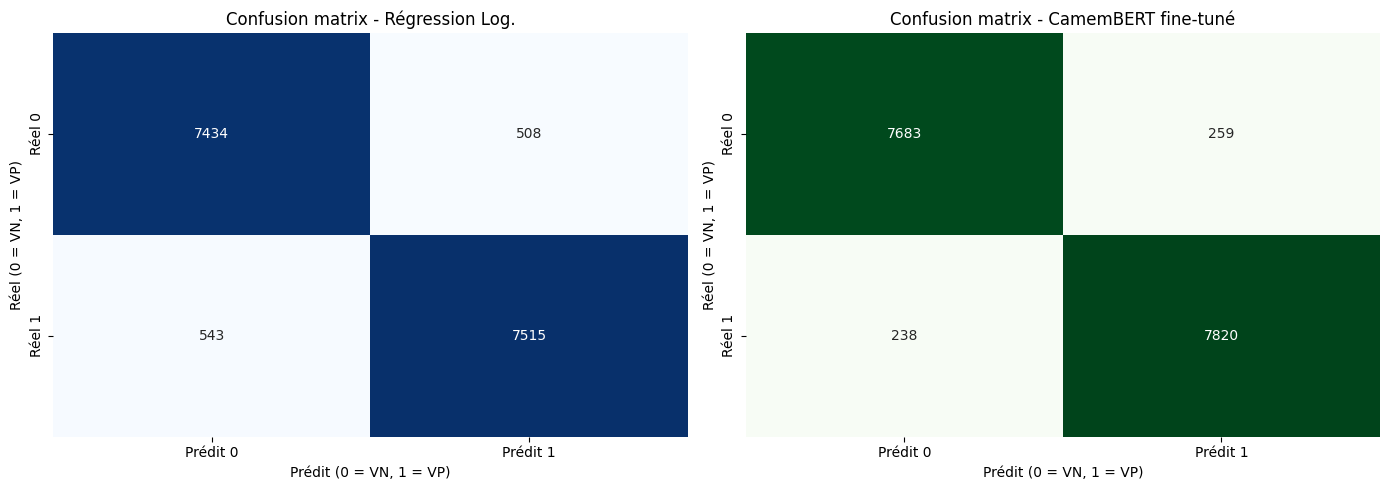

In [ ]:
# Matrices de confusion côte à côte pour le modèle ML et CamemBERT
ml_model_name = next((name for name in benchmark_df.index if name != 'CamemBERT fine-tuné'), benchmark_df.index[0])
bert_model_name = 'CamemBERT fine-tuné'

ml_true = np.asarray(y_test)
ml_pred = prediction_store[ml_model_name]['y_pred']
bert_pred = prediction_store[bert_model_name]['y_pred']

cm_ml = confusion_matrix(ml_true, ml_pred)
cm_bert = confusion_matrix(ml_true, bert_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    cm_ml,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[0],
    xticklabels=['Prédit 0', 'Prédit 1'],
    yticklabels=['Réel 0', 'Réel 1']
)
axes[0].set_title(f'Confusion matrix - {ml_model_name}')
axes[0].set_xlabel('Prédit (0 = VN, 1 = VP)')
axes[0].set_ylabel('Réel (0 = VN, 1 = VP)')

sns.heatmap(
    cm_bert,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    ax=axes[1],
    xticklabels=['Prédit 0', 'Prédit 1'],
    yticklabels=['Réel 0', 'Réel 1']
)
axes[1].set_title('Confusion matrix - CamemBERT fine-tuné')
axes[1].set_xlabel('Prédit (0 = VN, 1 = VP)')
axes[1].set_ylabel('Réel (0 = VN, 1 = VP)')

plt.tight_layout()
plt.show()

## 4.5 Courbes ROC superposées

On superpose les courbes ROC pour comparer directement le compromis sensibilité/spécificité. La diagonale pointillée sert de base aléatoire: plus la courbe s'en éloigne, meilleur est le modèle.

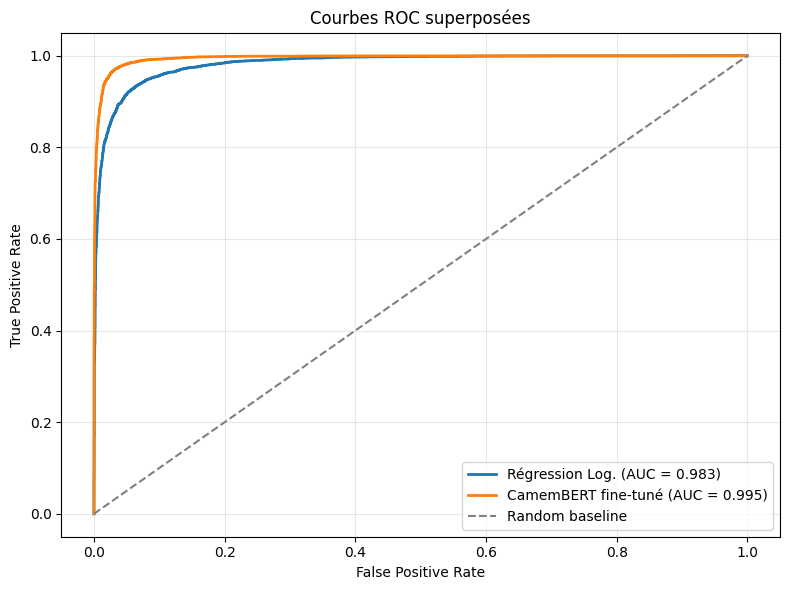

AUC ML   : 0.9825
AUC BERT : 0.9950


In [ ]:
# Courbes ROC superposées pour le meilleur modèle ML et CamemBERT
ml_scores = prediction_store[ml_model_name]['y_score']
bert_scores = prediction_store[bert_model_name]['y_score']

fpr_ml, tpr_ml, _ = roc_curve(ml_true, ml_scores)
fpr_bert, tpr_bert, _ = roc_curve(ml_true, bert_scores)
auc_ml = roc_auc_score(ml_true, ml_scores)
auc_bert = roc_auc_score(ml_true, bert_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ml, tpr_ml, label=f'{ml_model_name} (AUC = {auc_ml:.3f})', linewidth=2)
plt.plot(fpr_bert, tpr_bert, label=f'CamemBERT fine-tuné (AUC = {auc_bert:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
plt.title('Courbes ROC superposées')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC ML   : {auc_ml:.4f}')
print(f'AUC BERT : {auc_bert:.4f}')

# Phase 5 — Application Gradio sur HuggingFace Spaces

Objectif: transformer les modèles entraînés en démo web publique, reproductible et partageable via HuggingFace Spaces.


## 5.1 Présentation de l'architecture

On sépare clairement l'architecture en trois couches: modèles (HF Hub), application (app.py Gradio), et déploiement (Space). Cette séparation simplifie la maintenance et permet de mettre à jour les modèles sans réécrire l'interface.

In [ ]:
# Vue d'ensemble de l'architecture de déploiement
space_url = 'https://huggingface.co/spaces/bdjs-hugging/allocine_sentiment'
ml_repo_id = 'bdjs-hugging/allocine-sentiment-ml'
bert_repo_id = 'bdjs-hugging/allocine-sentiment-camembert'
space_repo_id = 'bdjs-hugging/allocine_sentiment'

print('Architecture cible:')
print('1) Upload des modèles vers le Hub')
print('2) Génération de app.py + requirements.txt en local Colab (/content)')
print('3) Upload des fichiers app vers le Space Gradio')
print('4) Test de la démo live:', space_url)

Architecture cible:
1) Upload des modèles vers le Hub
2) Génération de app.py + requirements.txt en local Colab (/content)
3) Upload des fichiers app vers le Space Gradio
4) Test de la démo live: https://huggingface.co/spaces/bdjs-hugging/allocine_sentiment


## 5.2 Upload des modèles sur HuggingFace Hub

Avant l'upload, on s'authentifie avec un token stocké dans Colab Secrets pour éviter d'exposer les identifiants dans le notebook. Ensuite, on pousse le pipeline ML et le dossier CamemBERT dans deux repos modèles distincts.

In [ ]:
# Authentification HuggingFace depuis Colab
# HF_TOKEN doit être ajouté dans Colab > Secrets
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get('hf_token')
if hf_token is None:
    raise ValueError('hf_token introuvable dans Colab Secrets')

login(token=hf_token)
print(' Authentification HuggingFace réussie')

✅ Authentification HuggingFace réussie


In [ ]:
# Upload des modèles vers HuggingFace Hub
from huggingface_hub import HfApi

api = HfApi()

# Créer les repos modèles
api.create_repo(repo_id='bdjs-hugging/allocine-sentiment-ml', repo_type='model', exist_ok=True)
api.create_repo(repo_id='bdjs-hugging/allocine-sentiment-camembert', repo_type='model', exist_ok=True)

# Uploader model_ml.pkl
api.upload_file(
    path_or_fileobj='/content/drive/MyDrive/TP_NLP/model_ml.pkl',
    path_in_repo='model_ml.pkl',
    repo_id='bdjs-hugging/allocine-sentiment-ml',
    repo_type='model'
)

# Uploader le dossier CamemBERT complet
api.upload_folder(
    folder_path='/content/drive/MyDrive/TP_NLP/camembert_sentiment',
    repo_id='bdjs-hugging/allocine-sentiment-camembert',
    repo_type='model'
)

print('✅ Modèles uploadés sur le Hub')
print('ML repo   : https://huggingface.co/bdjs-hugging/allocine-sentiment-ml')
print('BERT repo : https://huggingface.co/bdjs-hugging/allocine-sentiment-camembert')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...Drive/TP_NLP/model_ml.pkl:  28%|##8       |  679kB / 2.39MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ntiment/model.safetensors:   0%|          | 1.65MB /  443MB            

  ...ntiment/training_args.bin:   1%|1         |  71.0B / 5.20kB            

✅ Modèles uploadés sur le Hub
ML repo   : https://huggingface.co/bdjs-hugging/allocine-sentiment-ml
BERT repo : https://huggingface.co/bdjs-hugging/allocine-sentiment-camembert


## 5.3 Code de l'application (app.py)

On génère app.py directement depuis le notebook pour garder un workflow 100% Colab. L'application charge les modèles depuis le Hub et met en cache le chargement afin d'éviter les rechargements à chaque requête utilisateur.

In [ ]:
readme = '''---
title: Allocine Sentiment
emoji: 🎬
colorFrom: blue
colorTo: red
sdk: gradio
sdk_version: 4.36.0
app_file: app.py
pinned: false
python_version: 3.11
---
'''
with open('/content/README.md', 'w', encoding='utf-8') as f:
    f.write(readme)
print('✅ README.md généré')

✅ README.md généré


In [ ]:
app_code = r'''
import gradio as gr
import traceback
import joblib
from huggingface_hub import hf_hub_download
from transformers import pipeline

ML_REPO_ID   = "bdjs-hugging/allocine-sentiment-ml"
BERT_REPO_ID = "bdjs-hugging/allocine-sentiment-camembert"


def _label_to_text(label_int: int) -> str:
    return "✅ Positif" if int(label_int) == 1 else "❌ Négatif"


def _bert_label_to_int(label: str) -> int:
    normalized = str(label).upper()
    if normalized in ["LABEL_1", "POSITIVE", "POS"]:
        return 1
    return 0


def load_models():
    ml_path  = hf_hub_download(repo_id=ML_REPO_ID, filename="model_ml.pkl")
    model_ml = joblib.load(ml_path)
    bert_pipe = pipeline(
        "text-classification",
        model=BERT_REPO_ID,
        tokenizer="camembert-base",
        device=-1  # CPU — HuggingFace Spaces gratuit
    )
    return model_ml, bert_pipe


try:
    MODEL_ML, BERT_PIPE = load_models()
    LOAD_ERROR = None
except Exception as e:
    MODEL_ML, BERT_PIPE = None, None
    LOAD_ERROR = f"Erreur de chargement des modèles: {e}"


def analyze_review(review: str):
    if LOAD_ERROR is not None:
        return "Erreur", 0.0, "Erreur", 0.0, LOAD_ERROR

    if review is None or len(review.strip()) == 0:
        return "Texte vide", 0.0, "Texte vide", 0.0, \
               "Veuillez saisir un avis avant de lancer l'analyse."

    try:
        # --- Modèle ML Classique ---
        ml_pred = int(MODEL_ML.predict([review])[0])
        if hasattr(MODEL_ML, "predict_proba"):
            ml_probs = MODEL_ML.predict_proba([review])[0]
            ml_conf  = float(ml_probs[ml_pred]) * 100.0
        else:
            ml_conf  = 50.0
        ml_label = _label_to_text(ml_pred)

        # --- Modèle CamemBERT ---
        bert_out  = BERT_PIPE(review, truncation=True, max_length=256)[0]
        bert_pred = _bert_label_to_int(bert_out.get("label", "LABEL_0"))
        bert_conf = float(bert_out.get("score", 0.0)) * 100.0
        bert_label = _label_to_text(bert_pred)

        # --- Accord entre modèles ---
        if ml_pred == bert_pred:
            agreement_msg = "✅ Les deux modèles sont d'accord"
        else:
            agreement_msg = "⚠️ Les deux modèles sont en désaccord"

        return ml_label, round(ml_conf, 2), bert_label, round(bert_conf, 2), agreement_msg

    except Exception as e:
        trace = traceback.format_exc(limit=1)
        return "Erreur", 0.0, "Erreur", 0.0, f"Erreur d'inférence: {e}\n{trace}"


with gr.Blocks(title="Analyse de Sentiment — Allocine") as demo:
    gr.Markdown("""
# 🎬 Analyse de Sentiment — Avis de Films Français (Allocine)
Cette application compare deux approches NLP pour classer un avis en **positif** ou **négatif** :
- 🤖 **ML Classique** : TF-IDF + classifieur Scikit-learn
- 🧠 **CamemBERT fine-tuné** : Transformer entraîné sur le français
""")

    user_text = gr.Textbox(
        label="Avis de film",
        placeholder="Exemple : Ce film ne m'a pas déçu, excellente surprise !",
        lines=5,
    )
    analyze_btn = gr.Button("🔍 Analyser", variant="primary")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 🤖 ML Classique")
            ml_label_out = gr.Textbox(label="Prédiction")
            ml_conf_out  = gr.Number(label="Confiance (%)")
        with gr.Column():
            gr.Markdown("### 🧠 CamemBERT")
            bert_label_out = gr.Textbox(label="Prédiction")
            bert_conf_out  = gr.Number(label="Confiance (%)")

    agreement_out = gr.Textbox(label="Accord entre modèles")

    gr.Examples(
        examples=[
            ["Un chef-d'oeuvre absolu, acteurs brillants et mise en scène époustouflante."],
            ["Film magnifique, émouvant et profondément humain."],
            ["Une excellente surprise, scénario intelligent et rythme parfait."],
            ["Film ennuyeux, scénario nul et acteurs peu convaincants."],
            ["Deux heures perdues, c'est long et sans intérêt."],
            ["Très déçu, aucune émotion et réalisation ratée."],
        ],
        inputs=[user_text],
        label="Exemples d'avis"
    )

    analyze_btn.click(
        fn=analyze_review,
        inputs=[user_text],
        outputs=[ml_label_out, ml_conf_out, bert_label_out, bert_conf_out, agreement_out],
    )

demo.launch()
'''

with open('/content/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print('✅ Fichier généré : /content/app.py')
print('Taille (caractères):', len(app_code))

✅ Fichier généré : /content/app.py
Taille (caractères): 4261


## 5.4 Fichier requirements.txt

Le Space reconstruit l'environnement à partir de requirements.txt. On fige les dépendances essentielles pour éviter les erreurs au build et garantir un démarrage reproductible.

In [ ]:
requirements_txt = '''transformers==4.46.0
torch==2.5.1
scikit-learn==1.5.2
sentencepiece==0.2.0
joblib==1.4.2
'''

with open('/content/requirements.txt', 'w', encoding='utf-8') as f:
    f.write(requirements_txt)
print('✅ requirements.txt généré')
print(requirements_txt)

✅ requirements.txt généré
transformers==4.46.0
torch==2.5.1
scikit-learn==1.5.2
sentencepiece==0.2.0
joblib==1.4.2



## 5.5 Déploiement sur HuggingFace Spaces via API

On pousse app.py et requirements.txt par API directement depuis Colab. Cela évite les manipulations manuelles et permet de versionner le déploiement en quelques cellules reproductibles.

In [ ]:
from huggingface_hub import HfApi
api = HfApi()

# Crée le Space si nécessaire (SDK Gradio)
api.create_repo(
    repo_id='bdjs-hugging/allocine_sentiment',
    repo_type='space',
    space_sdk='gradio',
    exist_ok=True,
)

# Upload des 3 fichiers dans l'ordre
for filename in ['README.md', 'requirements.txt', 'app.py']:
    api.upload_file(
        path_or_fileobj=f'/content/{filename}',
        path_in_repo=filename,
        repo_id='bdjs-hugging/allocine_sentiment',
        repo_type='space'
    )
    print(f'✅ {filename} uploadé')

print('\n🚀 Space rebuild en cours...')
print('👉 https://huggingface.co/spaces/bdjs-hugging/allocine_sentiment')

No files have been modified since last commit. Skipping to prevent empty commit.


✅ README.md uploadé


No files have been modified since last commit. Skipping to prevent empty commit.


✅ requirements.txt uploadé
✅ app.py uploadé

🚀 Space rebuild en cours...
👉 https://huggingface.co/spaces/bdjs-hugging/allocine_sentiment


## 5.6 Test de la démo live

La dernière étape consiste à ouvrir le Space, attendre le build, puis tester plusieurs avis pour vérifier la cohérence des deux modèles et la gestion des cas de désaccord.